In [1]:
# Veri kaynakları:
# Online Retail: https://archive.ics.uci.edu/dataset/352/online+retail
# TCMB EVDS: https://evds2.tcmb.gov.tr/
# OECD/FRED USD-TRY: https://fred.stlouisfed.org/series/CCUSMA02TRM618N

# Gerekli paketler bilgisayarında yoksa bu hücreyi bir kez çalıştır.
%pip install -q pandas numpy openpyxl matplotlib seaborn scikit-learn xgboost shap reportlab


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="deep")

DATA_DIR = Path(".")
SALES_PATH = DATA_DIR / "online_retail.csv"
MACRO_PATH = DATA_DIR / "evds_veri.xlsx"
FX_PATH = DATA_DIR / "usdtry_aylik.csv"

for path in [SALES_PATH, MACRO_PATH, FX_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Eksik dosya: {path.resolve()}")
print("Girdi dosyaları hazır.")


Girdi dosyaları hazır.


In [3]:
# Satış verisini temizle
sales = pd.read_csv(SALES_PATH, encoding="unicode_escape")
sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"], errors="coerce")
sales = sales[
    sales["InvoiceDate"].notna()
    & sales["Description"].notna()
    & (sales["Quantity"] > 0)
    & (sales["UnitPrice"] > 0)
].copy()
sales["StockCode"] = sales["StockCode"].astype(str)

# Çok az sayıdaki olağan dışı toplu kayıt model ve kâr sonuçlarını tek başına sürüklemesin.
# Üst %0,01'lik işlem miktarı aykırı değer kabul edilir; eşik raporlanır.
quantity_cap = sales["Quantity"].quantile(0.9999)
outlier_count = int((sales["Quantity"] > quantity_cap).sum())
sales = sales[sales["Quantity"] <= quantity_cap].copy()
sales["Satis_Tutari"] = sales["Quantity"] * sales["UnitPrice"]
sales["Hafta_Baslangici"] = (
    sales["InvoiceDate"].dt.normalize()
    - pd.to_timedelta(sales["InvoiceDate"].dt.dayofweek, unit="D")
)

# Modelin çalışmasını hızlandırmak ve ticari etkiyi korumak için cirodaki ilk 500 ürün
top_products = (
    sales.groupby("StockCode")["Satis_Tutari"].sum()
    .nlargest(500).index
)
sales = sales[sales["StockCode"].isin(top_products)].copy()

print(f"Temiz işlem sayısı: {len(sales):,}")
print(f"Ürün sayısı: {sales['StockCode'].nunique():,}")
print(f"Aykırı miktar eşiği: {quantity_cap:,.0f}; çıkarılan işlem: {outlier_count}")
print(f"Tarih aralığı: {sales['InvoiceDate'].min().date()} - {sales['InvoiceDate'].max().date()}")


Temiz işlem sayısı: 249,660
Ürün sayısı: 500
Aykırı miktar eşiği: 1,440; çıkarılan işlem: 54
Tarih aralığı: 2010-12-01 - 2011-12-09


In [4]:
# Aylık güven endeksi
macro = pd.read_excel(MACRO_PATH).iloc[:, :2].copy()
macro.columns = ["Yil_Ay_Ham", "Guven_Endeksi"]
macro["Yil_Ay"] = pd.to_datetime(macro["Yil_Ay_Ham"], errors="coerce").dt.to_period("M")
macro["Guven_Endeksi"] = pd.to_numeric(macro["Guven_Endeksi"], errors="coerce")
macro = macro.dropna(subset=["Yil_Ay", "Guven_Endeksi"])[["Yil_Ay", "Guven_Endeksi"]]

# Aylık USD/TRY ortalama kuru
fx = pd.read_csv(FX_PATH)
fx["Tarih"] = pd.to_datetime(fx["Tarih"])
fx["Yil_Ay"] = fx["Tarih"].dt.to_period("M")
fx["Dolar_Kuru"] = pd.to_numeric(fx["Dolar_Kuru"], errors="coerce")
fx = fx.dropna(subset=["Yil_Ay", "Dolar_Kuru"])[["Yil_Ay", "Dolar_Kuru"]]
fx = fx.sort_values("Yil_Ay")
fx["Kur_Degisimi_1A"] = fx["Dolar_Kuru"].pct_change().fillna(0)
fx["Kur_Volatilitesi_3A"] = fx["Kur_Degisimi_1A"].rolling(3, min_periods=2).std().fillna(0)

display(macro.head())
display(fx.head())


,Yil_Ay,Guven_Endeksi
0,2010-12,91.0
1,2011-01,91.3
2,2011-02,93.6
3,2011-03,93.4
4,2011-04,93.5


,Yil_Ay,Dolar_Kuru,Kur_Degisimi_1A,Kur_Volatilitesi_3A
0,2010-12,1.514822,0.000000,0.000000
1,2011-01,1.556748,0.027677,0.019571
2,2011-02,1.582515,0.016552,0.013927
3,2011-03,1.572213,-0.006510,0.017437
4,2011-04,1.514562,-0.036669,0.026689


In [5]:
# Önce ürün-hafta seviyesine toplulaştır
weekly_raw = (
    sales.groupby(["Hafta_Baslangici", "StockCode"], as_index=False)
    .agg(
        Quantity=("Quantity", "sum"),
        UnitPrice=("UnitPrice", "median"),
        Satis_Tutari=("Satis_Tutari", "sum"),
        Description=("Description", "first"),
    )
)

# Satış olmayan haftaların da gerçekten 0 talep olarak görünmesi için dengeli panel
all_weeks = pd.date_range(
    weekly_raw["Hafta_Baslangici"].min(),
    weekly_raw["Hafta_Baslangici"].max(),
    freq="W-MON",
)
panel_index = pd.MultiIndex.from_product(
    [all_weeks, top_products], names=["Hafta_Baslangici", "StockCode"]
)
weekly = weekly_raw.set_index(["Hafta_Baslangici", "StockCode"]).reindex(panel_index).reset_index()
weekly["Quantity"] = weekly["Quantity"].fillna(0)
weekly["Satis_Tutari"] = weekly["Satis_Tutari"].fillna(0)
weekly["UnitPrice"] = weekly.groupby("StockCode")["UnitPrice"].transform(lambda s: s.ffill().bfill())
weekly["Description"] = weekly.groupby("StockCode")["Description"].transform(lambda s: s.ffill().bfill())
weekly = weekly.dropna(subset=["UnitPrice"]).copy()

# Üç veri kaynağını ay anahtarıyla birleştir
weekly["Yil_Ay"] = weekly["Hafta_Baslangici"].dt.to_period("M")
weekly = weekly.merge(fx, on="Yil_Ay", how="left").merge(macro, on="Yil_Ay", how="left")
weekly[["Dolar_Kuru", "Kur_Degisimi_1A", "Kur_Volatilitesi_3A", "Guven_Endeksi"]] = (
    weekly[["Dolar_Kuru", "Kur_Degisimi_1A", "Kur_Volatilitesi_3A", "Guven_Endeksi"]]
    .ffill().bfill()
)

print("Birleşmiş haftalık veri boyutu:", weekly.shape)
display(weekly.head())


Birleşmiş haftalık veri boyutu: (27000, 11)


,Hafta_Baslangici,StockCode,Quantity,UnitPrice,Satis_Tutari,Description,Yil_Ay,Dolar_Kuru,Kur_Degisimi_1A,Kur_Volatilitesi_3A,Guven_Endeksi
0,2010-11-29,DOT,6.0,534.12,2938.74,DOTCOM POSTAGE,2010-11,1.514822,0.0,0.0,91.0
1,2010-11-29,22423,622.0,12.75,7717.95,REGENCY CAKESTAND 3 TIER,2010-11,1.514822,0.0,0.0,91.0
2,2010-11-29,47566,19.0,4.65,114.67,PARTY BUNTING,2010-11,1.514822,0.0,0.0,91.0
3,2010-11-29,85123A,986.0,2.95,2636.38,WHITE HANGING HEART T-LIGHT HOLDER,2010-11,1.514822,0.0,0.0,91.0
4,2010-11-29,85099B,692.0,1.95,1217.48,JUMBO BAG RED RETROSPOT,2010-11,1.514822,0.0,0.0,91.0


In [6]:
weekly = weekly.sort_values(["StockCode", "Hafta_Baslangici"]).reset_index(drop=True)
g = weekly.groupby("StockCode", group_keys=False)

# 1) Geçmiş talep özellikleri
weekly["Gecen_Hafta_Miktar"] = g["Quantity"].shift(1)
weekly["Iki_Hafta_Once_Miktar"] = g["Quantity"].shift(2)
weekly["Talep_Ort_4H"] = g["Quantity"].transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())

# 2) Ürün-hafta düzeyinde fiyat esnekliği
qty_change = g["Quantity"].pct_change().replace([np.inf, -np.inf], np.nan)
price_change = g["UnitPrice"].pct_change().replace(0, np.nan)
elasticity_raw = (qty_change / price_change).replace([np.inf, -np.inf], np.nan)
elasticity_raw = elasticity_raw.where(price_change.abs() >= 0.01)
weekly["Esneklik_Ham"] = elasticity_raw
weekly["Esneklik"] = g["Esneklik_Ham"].transform(
    lambda s: s.shift(1).expanding(min_periods=1).median()
)
weekly["Esneklik"] = weekly["Esneklik"].clip(-5, 0).fillna(-1.0)

# 3) Makro risk ve takvim özellikleri
weekly["Makro_Risk_Bayragi"] = (weekly["Guven_Endeksi"] < 90).astype(int)
weekly["Ay"] = weekly["Hafta_Baslangici"].dt.month
weekly["Yil_Sonu_Bayragi"] = weekly["Ay"].isin([11, 12]).astype(int)

# Hedef: gerçek bir sonraki takvim haftasının miktarı
weekly["Gelecek_Hafta_Miktar"] = g["Quantity"].shift(-1)
weekly = weekly.dropna(subset=["Gecen_Hafta_Miktar", "Iki_Hafta_Once_Miktar", "Gelecek_Hafta_Miktar"])

feature_preview = [
    "StockCode", "Hafta_Baslangici", "Quantity", "Gecen_Hafta_Miktar",
    "Talep_Ort_4H", "Esneklik", "Kur_Volatilitesi_3A", "Makro_Risk_Bayragi"
]
display(weekly[feature_preview].head(10))


,StockCode,Hafta_Baslangici,Quantity,Gecen_Hafta_Miktar,Talep_Ort_4H,Esneklik,Kur_Volatilitesi_3A,Makro_Risk_Bayragi
2,15036,2010-12-13,35.0,21.0,48.000000,-1.018868,0.000000,0
3,15036,2010-12-20,30.0,35.0,43.666667,-1.018868,0.000000,0
4,15036,2010-12-27,0.0,30.0,40.250000,-0.164420,0.000000,0
5,15036,2011-01-03,18.0,0.0,21.500000,-0.164420,0.019571,0
6,15036,2011-01-10,159.0,18.0,20.750000,-0.164420,0.019571,0
7,15036,2011-01-17,39.0,159.0,51.750000,-1.018868,0.019571,0
8,15036,2011-01-24,112.0,39.0,54.000000,-0.164420,0.019571,0
9,15036,2011-01-31,1913.0,112.0,82.000000,0.000000,0.019571,0
10,15036,2011-02-07,68.0,1913.0,555.750000,-0.164420,0.013927,0
11,15036,2011-02-14,762.0,68.0,533.000000,-0.821978,0.013927,0


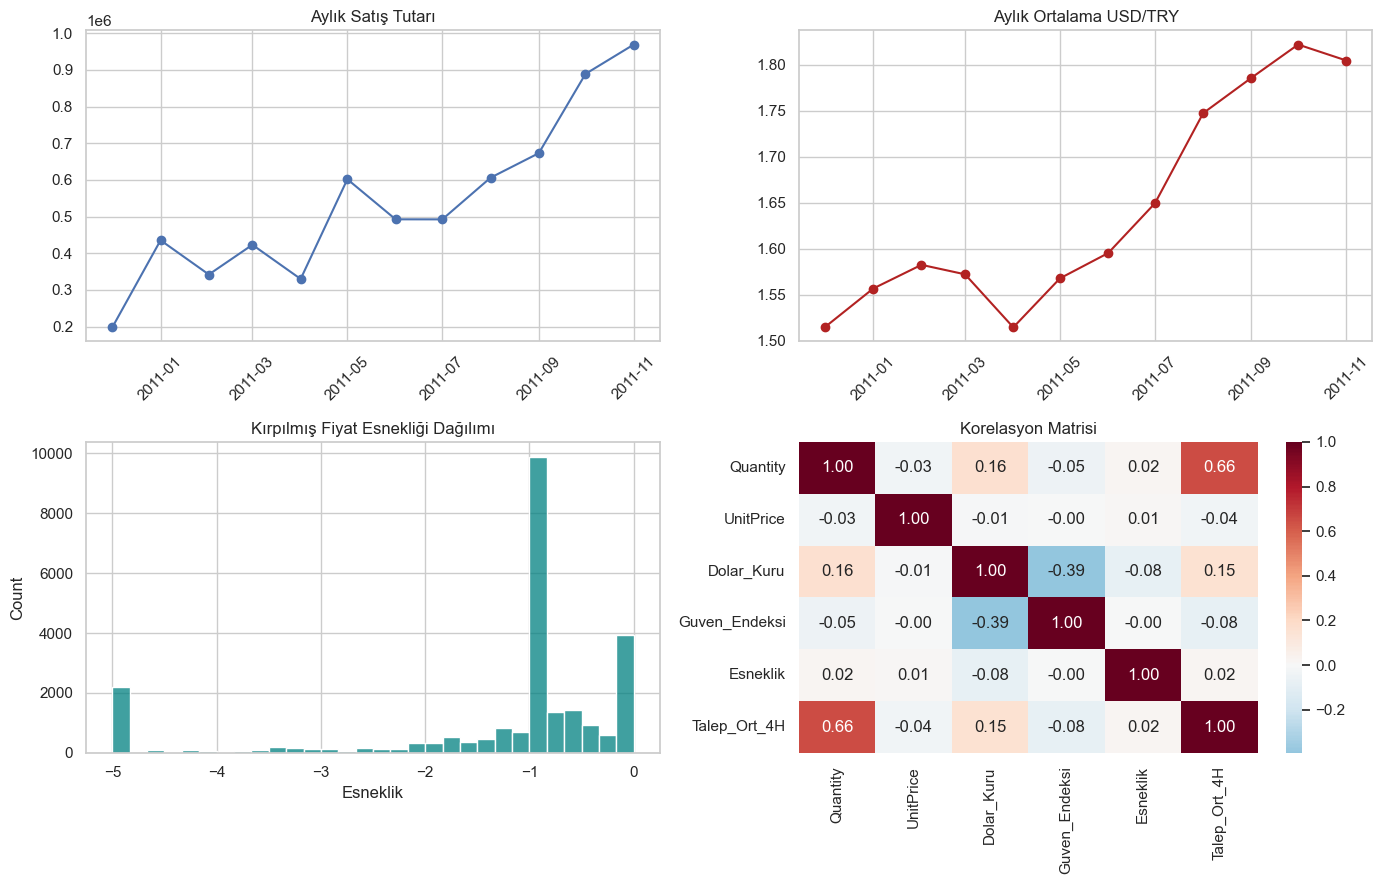

In [7]:
monthly_eda = (
    weekly.groupby("Yil_Ay", as_index=False)
    .agg(
        Satis_Tutari=("Satis_Tutari", "sum"),
        Quantity=("Quantity", "sum"),
        Dolar_Kuru=("Dolar_Kuru", "mean"),
        Guven_Endeksi=("Guven_Endeksi", "mean"),
    )
)
monthly_eda["Tarih"] = monthly_eda["Yil_Ay"].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(monthly_eda["Tarih"], monthly_eda["Satis_Tutari"], marker="o")
axes[0, 0].set_title("Aylık Satış Tutarı")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].plot(monthly_eda["Tarih"], monthly_eda["Dolar_Kuru"], color="firebrick", marker="o")
axes[0, 1].set_title("Aylık Ortalama USD/TRY")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.histplot(weekly["Esneklik"], bins=30, ax=axes[1, 0], color="teal")
axes[1, 0].set_title("Kırpılmış Fiyat Esnekliği Dağılımı")

corr_cols = ["Quantity", "UnitPrice", "Dolar_Kuru", "Guven_Endeksi", "Esneklik", "Talep_Ort_4H"]
sns.heatmap(weekly[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Korelasyon Matrisi")

plt.tight_layout()
plt.savefig("eda_ozet.png", dpi=200, bbox_inches="tight")
plt.show()


In [8]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

FEATURES = [
    "Quantity", "Gecen_Hafta_Miktar", "Iki_Hafta_Once_Miktar", "Talep_Ort_4H",
    "UnitPrice", "Dolar_Kuru", "Kur_Degisimi_1A", "Kur_Volatilitesi_3A",
    "Guven_Endeksi", "Makro_Risk_Bayragi", "Esneklik", "Ay", "Yil_Sonu_Bayragi"
]
TARGET = "Gelecek_Hafta_Miktar"

model_df = weekly.dropna(subset=FEATURES + [TARGET]).sort_values("Hafta_Baslangici").reset_index(drop=True)
unique_dates = np.array(sorted(model_df["Hafta_Baslangici"].unique()))
cutoff = unique_dates[int(len(unique_dates) * 0.80)]
train_mask = model_df["Hafta_Baslangici"] < cutoff
test_mask = ~train_mask

X_train, y_train = model_df.loc[train_mask, FEATURES], model_df.loc[train_mask, TARGET]
X_test, y_test = model_df.loc[test_mask, FEATURES], model_df.loc[test_mask, TARGET]

# Aynı haftayı eğitim ve doğrulama arasında bölmeyen özel zaman serisi katları
train_dates = np.array(sorted(model_df.loc[train_mask, "Hafta_Baslangici"].unique()))
folds = []
for frac in [0.55, 0.70, 0.85]:
    split = max(2, int(len(train_dates) * frac))
    val_end = min(len(train_dates), split + max(2, len(train_dates) // 10))
    tr_dates, va_dates = train_dates[:split], train_dates[split:val_end]
    tr_idx = np.flatnonzero(model_df.loc[train_mask, "Hafta_Baslangici"].isin(tr_dates).to_numpy())
    va_idx = np.flatnonzero(model_df.loc[train_mask, "Hafta_Baslangici"].isin(va_dates).to_numpy())
    if len(va_idx):
        folds.append((tr_idx, va_idx))

baseline = DummyRegressor(strategy="median").fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

base_model = XGBRegressor(
    objective="reg:squarederror", random_state=42, n_jobs=-1,
    tree_method="hist"
)
param_dist = {
    "n_estimators": [150, 250, 350],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.06, 0.10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}
search = RandomizedSearchCV(
    base_model, param_dist, n_iter=6, scoring="neg_root_mean_squared_error",
    cv=folds, random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)
model = search.best_estimator_
pred = np.clip(model.predict(X_test), 0, None)

def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

metric_table = pd.DataFrame({
    "Medyan Temel Model": metrics(y_test, baseline_pred),
    "XGBoost": metrics(y_test, pred),
}).T

print("Zaman bazlı ayrım tarihi:", pd.Timestamp(cutoff).date())
print("En iyi parametreler:", search.best_params_)
display(metric_table.round(3))


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Zaman bazlı ayrım tarihi: 2011-09-19
En iyi parametreler: {'subsample': 0.8, 'n_estimators': 350, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


,MAE,RMSE,R2
Medyan Temel Model,133.538,276.788,-0.251
XGBoost,95.921,195.136,0.378


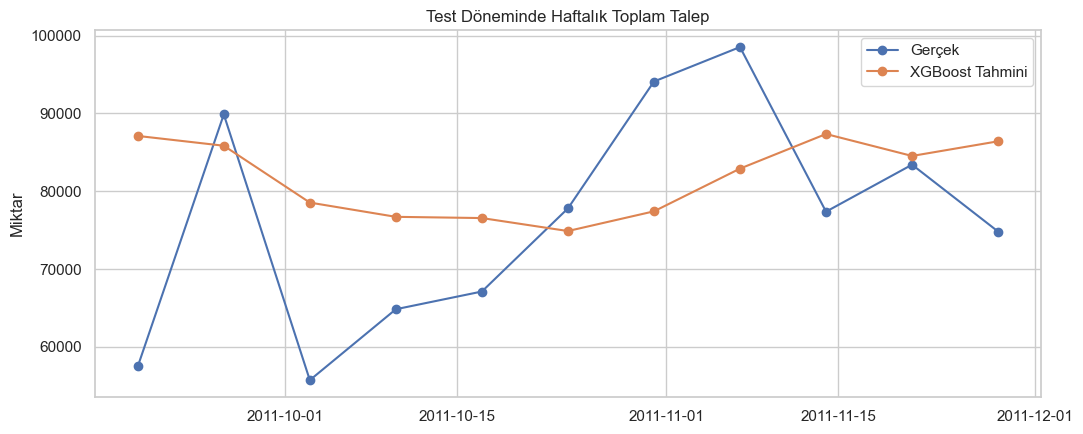

In [9]:
# Gerçek ve tahmini talep karşılaştırması
prediction_plot = pd.DataFrame({
    "Tarih": model_df.loc[test_mask, "Hafta_Baslangici"].to_numpy(),
    "Gercek": y_test.to_numpy(),
    "Tahmin": pred,
}).groupby("Tarih", as_index=False).sum()

plt.figure(figsize=(11, 4.5))
plt.plot(prediction_plot["Tarih"], prediction_plot["Gercek"], label="Gerçek", marker="o")
plt.plot(prediction_plot["Tarih"], prediction_plot["Tahmin"], label="XGBoost Tahmini", marker="o")
plt.title("Test Döneminde Haftalık Toplam Talep")
plt.ylabel("Miktar")
plt.legend()
plt.tight_layout()
plt.savefig("model_tahmin.png", dpi=200, bbox_inches="tight")
plt.show()


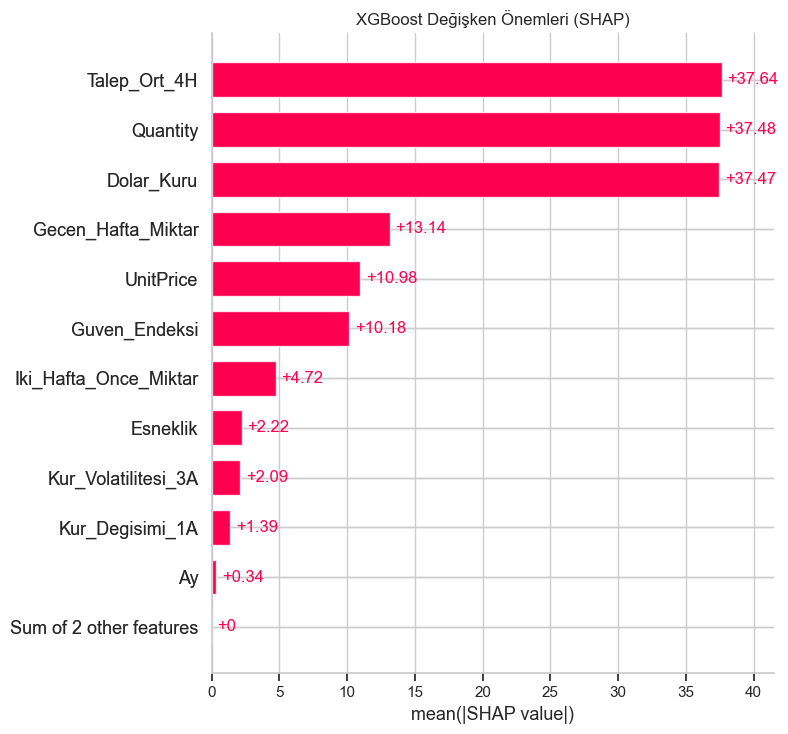

In [10]:
import shap

sample_size = min(1500, len(X_test))
X_explain = X_test.sample(sample_size, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_explain)

shap.plots.bar(shap_values, max_display=12, show=False)
plt.title("XGBoost Değişken Önemleri (SHAP)")
plt.tight_layout()
plt.savefig("shap_grafigi.png", dpi=200, bbox_inches="tight")
plt.show()


In [11]:
# Test döneminin en son haftasına ait, model tarafından tahmin edilmiş gelecek hafta talebi
test_rows = model_df.loc[test_mask].copy()
test_rows["Tahmini_Talep"] = pred
sim_date = test_rows["Hafta_Baslangici"].max()
sim = test_rows[test_rows["Hafta_Baslangici"] == sim_date].copy()

KUR_SOKU = 0.05
BRUT_KAR_MARJI = 0.30
DOVIZE_DUYARLI_MALIYET_PAYI = 0.40
UYGULAMA_MALIYETI = 2500.0
PRICE_GRID = np.arange(-0.05, 0.1001, 0.005)

sim["Birim_Maliyet"] = sim["UnitPrice"] * (1 - BRUT_KAR_MARJI)
sim["Sok_Sonrasi_Birim_Maliyet"] = sim["Birim_Maliyet"] * (
    1 + KUR_SOKU * DOVIZE_DUYARLI_MALIYET_PAYI
)

scenario_rows = []
for idx, row in sim.iterrows():
    for price_change in PRICE_GRID:
        new_price = row["UnitPrice"] * (1 + price_change)
        new_demand = max(row["Tahmini_Talep"] * (1 + row["Esneklik"] * price_change), 0)
        profit = (new_price - row["Sok_Sonrasi_Birim_Maliyet"]) * new_demand
        scenario_rows.append((idx, price_change, new_price, new_demand, profit))

scenarios = pd.DataFrame(
    scenario_rows,
    columns=["Satir", "Fiyat_Degisimi", "Yeni_Fiyat", "Yeni_Talep", "Beklenen_Kar"]
)
best = scenarios.loc[scenarios.groupby("Satir")["Beklenen_Kar"].idxmax()].set_index("Satir")
sim = sim.join(best[["Fiyat_Degisimi", "Yeni_Fiyat", "Yeni_Talep", "Beklenen_Kar"]])

def portfolio_profit(price_change):
    demand = np.maximum(sim["Tahmini_Talep"] * (1 + sim["Esneklik"] * price_change), 0)
    price = sim["UnitPrice"] * (1 + price_change)
    return float(((price - sim["Sok_Sonrasi_Birim_Maliyet"]) * demand).sum())

no_action_profit = portfolio_profit(0.00)
uniform_5_profit = portfolio_profit(0.05)
optimized_profit = float(sim["Beklenen_Kar"].sum())
incremental_profit = optimized_profit - no_action_profit
net_benefit = incremental_profit - UYGULAMA_MALIYETI
roi = net_benefit / UYGULAMA_MALIYETI

financial_summary = pd.DataFrame({
    "Senaryo": ["Fiyat değişikliği yok", "Tüm ürünlere %5 zam", "Ürün bazlı optimize fiyat"],
    "Beklenen Haftalık Kâr": [no_action_profit, uniform_5_profit, optimized_profit],
})
financial_summary["Değişiklik Yok Senaryosuna Göre Fark"] = (
    financial_summary["Beklenen Haftalık Kâr"] - no_action_profit
)

print("Simülasyon haftası:", sim_date.date())
display(financial_summary.round(2))
print(f"Uygulama maliyeti sonrası net fayda: {net_benefit:,.2f}")
print(f"ROI: %{roi * 100:,.2f}")
display(
    sim[["StockCode", "Description", "Esneklik", "Tahmini_Talep", "Fiyat_Degisimi", "Beklenen_Kar"]]
    .sort_values("Beklenen_Kar", ascending=False).head(10)
)


Simülasyon haftası: 2011-11-28


,Senaryo,Beklenen Haftalık Kâr,Değişiklik Yok Senaryosuna Göre Fark
0,Fiyat değişikliği yok,169731.42,0.00
1,Tüm ürünlere %5 zam,188318.02,18586.60
2,Ürün bazlı optimize fiyat,206865.96,37134.54


Uygulama maliyeti sonrası net fayda: 34,634.54
ROI: %1,385.38


,StockCode,Description,Esneklik,Tahmini_Talep,Fiyat_Degisimi,Beklenen_Kar
25002,B,Adjust bad debt,-1.000000,26.655275,0.100,102435.147450
25007,DOT,DOTCOM POSTAGE,0.000000,38.128872,0.100,13075.538622
25008,AMAZONFEE,AMAZON FEE,-1.000000,26.655275,0.100,2034.986974
25089,22655,VINTAGE RED KITCHEN CABINET,-0.166667,29.126347,0.100,1381.923786
25381,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,-5.000000,24.646769,-0.045,1200.596471
25030,22423,REGENCY CAKESTAND 3 TIER,-1.000000,267.922150,0.100,1186.720974
25380,22826,LOVE SEAT ANTIQUE WHITE METAL,-1.000000,29.612095,0.100,874.415550
25215,22086,PAPER CHAIN KIT 50'S CHRISTMAS,-0.000000,653.565674,0.100,744.215233
25497,23084,RABBIT NIGHT LIGHT,-1.007149,995.874634,0.100,719.039412
25499,POST,POSTAGE,-1.000000,113.142044,0.100,707.499830


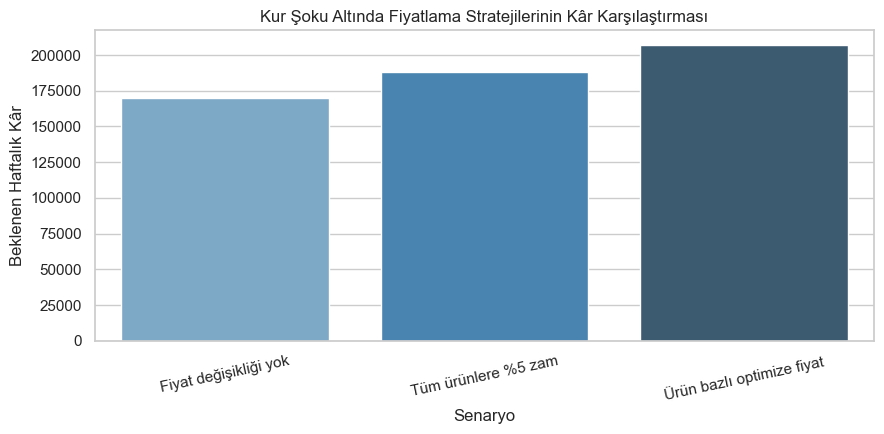

In [12]:
plt.figure(figsize=(9, 4.5))
sns.barplot(data=financial_summary, x="Senaryo", y="Beklenen Haftalık Kâr", palette="Blues_d")
plt.title("Kur Şoku Altında Fiyatlama Stratejilerinin Kâr Karşılaştırması")
plt.xticks(rotation=12)
plt.tight_layout()
plt.savefig("finansal_simulasyon.png", dpi=200, bbox_inches="tight")
plt.show()

sim.to_excel("optimizasyon_sonuclari.xlsx", index=False)
metric_table.to_excel("model_metrikleri.xlsx")


In [13]:
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
)

# Helvetica Türkçe karakterleri desteklemediği için Unicode font kaydet.
font_candidates = [
    (Path("C:/Windows/Fonts/arial.ttf"), Path("C:/Windows/Fonts/arialbd.ttf")),
    (Path("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"),
     Path("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf")),
]
for regular_path, bold_path in font_candidates:
    if regular_path.exists() and bold_path.exists():
        pdfmetrics.registerFont(TTFont("ReportFont", str(regular_path)))
        pdfmetrics.registerFont(TTFont("ReportFont-Bold", str(bold_path)))
        break
else:
    raise FileNotFoundError("Arial veya DejaVu Sans fontu bulunamadı.")

pdf_path = "Omer_Faruk_Ilan_Yonetici_Ozeti.pdf"
doc = SimpleDocTemplate(
    pdf_path, pagesize=A4,
    rightMargin=1.7*cm, leftMargin=1.7*cm,
    topMargin=1.5*cm, bottomMargin=1.5*cm,
)
styles = getSampleStyleSheet()
styles.add(ParagraphStyle(
    name="CenterTitle", parent=styles["Title"], alignment=TA_CENTER,
    textColor=colors.HexColor("#123A63"), fontSize=19, leading=23,
    fontName="ReportFont-Bold", spaceAfter=10
))
for style_name in ["Title", "Heading1", "Heading2", "Heading3"]:
    styles[style_name].fontName = "ReportFont-Bold"
styles["Normal"].fontName = "ReportFont"
styles["BodyText"].fontName = "ReportFont"
styles["Heading1"].textColor = colors.HexColor("#123A63")
styles["BodyText"].fontSize = 9.5
styles["BodyText"].leading = 13

def draw_page(canvas, document):
    canvas.saveState()
    width, height = A4
    canvas.setStrokeColor(colors.HexColor("#D5DEE8"))
    canvas.line(1.7*cm, height-1.0*cm, width-1.7*cm, height-1.0*cm)
    canvas.setFont("ReportFont", 8)
    canvas.setFillColor(colors.HexColor("#52677A"))
    canvas.drawString(1.7*cm, height-0.75*cm, "Dinamik Fiyatlama ve Kâr Optimizasyonu")
    canvas.drawRightString(width-1.7*cm, 0.75*cm, f"Sayfa {document.page}")
    canvas.restoreState()

story = [
    Paragraph("YÖNETİCİ ÖZETİ", styles["CenterTitle"]),
    Spacer(1, 8),
    Paragraph("Döviz Kuru Şoklarında Dinamik Fiyatlama ve Kâr Optimizasyonu", styles["Heading2"]),
    Spacer(1, 12),
    Paragraph("Ömer Faruk İlan - 132330060", styles["BodyText"]),
    Paragraph("YBS 4. Sınıf Python ile Veri Bilimi Dönem Sonu Projesi", styles["BodyText"]),
    Spacer(1, 18),
    Paragraph("1. İş Problemi ve Yönetici Kararı", styles["Heading1"]),
    Paragraph(
        "Kur artışı maliyetleri yükseltirken bütün ürünlere aynı zamı uygulamak, fiyat esnekliği yüksek ürünlerde talep ve kâr kaybı yaratabilir. Bu çalışma gelecek hafta talebini XGBoost ile tahmin etmekte ve her ürün için -%5 ile +%10 arasındaki fiyat seçeneklerini tarayarak beklenen kârı en yüksek yapan fiyatı seçmektedir.",
        styles["BodyText"]
    ),
    Spacer(1, 7),
    Paragraph("Projenin temel hedefi", styles["Heading2"]),
    Paragraph(
        "Amaç yalnızca satış miktarını tahmin etmek değildir. Asıl hedef; kur şoku gibi belirsiz bir dış koşul altında hangi üründe fiyatın korunacağına, hangi üründe zam yapılacağına ve uygulanacak oranın ne olacağına veriyle karar veren açıklanabilir bir yönetim destek sistemi geliştirmektir. Böylece teknik model çıktısı doğrudan finansal karara dönüştürülmektedir.",
        styles["BodyText"]
    ),
    Spacer(1, 7),
    Paragraph("Proje dört soruya cevap verir:", styles["Heading3"]),
    Paragraph(
        "1. Gelecek hafta her üründen yaklaşık kaç adet satılacaktır?<br/>"
        "2. Talep; geçmiş satışlar, fiyat, kur ve güven endeksinden nasıl etkilenmektedir?<br/>"
        "3. %5 kur şokunda sabit zam mı, ürün bazlı fiyatlama mı daha kârlıdır?<br/>"
        "4. Önerilen sistem uygulama maliyetini karşıladıktan sonra pozitif ROI üretmekte midir?",
        styles["BodyText"]
    ),
    Spacer(1, 10),
    Paragraph("Temel yönetici sonucu", styles["Heading2"]),
    Paragraph(
        f"%5 kur şoku senaryosunda ürün bazlı fiyat optimizasyonunun beklenen haftalık kârı {optimized_profit:,.2f}; fiyatı değiştirmeme senaryosuna göre brüt artış {incremental_profit:,.2f} ve 2.500 birim uygulama maliyeti sonrası ROI %{roi*100:,.2f} olarak hesaplanmıştır.",
        styles["BodyText"]
    ),
    PageBreak(),
    Paragraph("2. Veri Kaynakları ve Özellik Mühendisliği", styles["Heading1"]),
    Paragraph(
        "Online Retail işlem verileri; OECD/FRED USD/TRY aylık ortalama kur serisi ve TCMB EVDS Tüketici Güven Endeksi ile ay anahtarı üzerinden birleştirilmiştir. Veri seti haftalık ürün paneline dönüştürülmüş, satış olmayan haftalar sıfır talep olarak korunmuştur.",
        styles["BodyText"]
    ),
    Spacer(1, 8),
    Paragraph(
        "Ham işlem kayıtlarında iptal/negatif miktarlar, sıfır fiyatlar ve üst %0,01'lik aşırı miktarlar temizlenmiştir. En yüksek ticari etkiye sahip 500 ürün seçilmiş; günlük işlemler ürün-hafta düzeyinde toplulaştırılmıştır. Kur ve güven endeksi ay anahtarıyla bu panele eklenerek tek bir model tablosu oluşturulmuştur.",
        styles["BodyText"]
    ),
    Spacer(1, 10),
    Table(
        [["Yeni değişken", "İşletme anlamı"]] + [
            ["Fiyat esnekliği", "Fiyat değiştiğinde talebin verdiği tepkiyi ölçer."],
            ["Kur volatilitesi", "Kur piyasasındaki belirsizliğin kısa dönem göstergesidir."],
            ["Makro risk bayrağı", "Güven endeksi 90'ın altındaysa riskli dönemi işaretler."],
            ["4 haftalık talep ortalaması", "Kısa dönem satış eğilimini ve sürekliliği gösterir."],
            ["Gecikmeli miktarlar", "Son iki haftadaki talep bilgisini modele taşır."],
            ["Yıl sonu bayrağı", "Kasım-Aralık dönemindeki mevsimsel hareketi temsil eder."],
        ],
        colWidths=[5.2*cm, 11.0*cm]
    ),
    Spacer(1, 9),
    Image("eda_ozet.png", width=15.7*cm, height=8.7*cm),
    PageBreak(),
    Paragraph("3. Modelleme ve Açıklanabilir Yapay Zeka", styles["Heading1"]),
    Paragraph(
        f"Modelin hedef değişkeni her ürünün bir sonraki takvim haftasındaki satış miktarıdır. Gelecek bilgisinin eğitime sızmasını önlemek için veri kronolojik olarak ayrılmış; {pd.Timestamp(cutoff).date()} ve sonrası test dönemi olarak tutulmuştur. XGBoost hiperparametreleri yalnızca geçmiş dönemlerden geleceğe doğru ilerleyen zaman serisi katlarıyla seçilmiştir.",
        styles["BodyText"]
    ),
    Spacer(1, 7),
    Paragraph(
        "Model, basit bir medyan tahmin modeliyle karşılaştırılmıştır. MAE ortalama mutlak tahmin hatasını, RMSE büyük hatalara daha fazla ceza veren hata büyüklüğünü, R² ise talep değişiminin model tarafından açıklanan bölümünü gösterir. XGBoost'un işletme açısından anlamlı sayılabilmesi için temel modele göre MAE ve RMSE'yi düşürmesi beklenir.",
        styles["BodyText"]
    ),
    Spacer(1, 8),
    Table(
        [["Model", "MAE", "RMSE", "R²"]] + [
            [idx, f"{row['MAE']:.2f}", f"{row['RMSE']:.2f}", f"{row['R2']:.3f}"]
            for idx, row in metric_table.iterrows()
        ],
        colWidths=[7*cm, 3*cm, 3*cm, 2.5*cm]
    ),
    Spacer(1, 10),
    Paragraph(
        "SHAP analizi, modelin tahmin kararlarını hangi değişkenlerin ne ölçüde etkilediğini gösterir. Bu sayede model kara kutu olmaktan çıkar; yönetici geçmiş talebin, fiyatın ve makro göstergelerin tahmine katkısını karşılaştırabilir.",
        styles["BodyText"]
    ),
    Spacer(1, 7),
    Image("shap_grafigi.png", width=14.8*cm, height=8.2*cm),
    PageBreak(),
    Paragraph("4. Finansal Simülasyon, Varsayımlar ve Sınırlılıklar", styles["Heading1"]),
    Paragraph(
        "Kâr hesabında başlangıç brüt marjı %30, maliyetin dövize duyarlı payı %40 ve kur şoku %5 varsayılmıştır. Her ürün için -%5 ile +%10 arasındaki fiyat değişimleri 0,5 puanlık adımlarla denenmiştir. Her aday fiyat için esneklik kullanılarak yeni talep, ardından yeni fiyat ile şok sonrası birim maliyet arasındaki fark kullanılarak beklenen kâr hesaplanmıştır. En yüksek kârı sağlayan oran ürünün önerilen fiyat kararıdır.",
        styles["BodyText"]
    ),
    Spacer(1, 7),
    Paragraph(
        "Karar formülü özetle şöyledir: Yeni talep = model talebi × (1 + esneklik × fiyat değişimi). Beklenen kâr = (yeni fiyat - şok sonrası birim maliyet) × yeni talep. ROI ise fiyatı değiştirmeme senaryosuna göre oluşan ek kârdan 2.500 birim haftalık uygulama maliyeti düşülerek hesaplanmıştır.",
        styles["BodyText"]
    ),
    Spacer(1, 10),
    Table(
        [["Senaryo", "Beklenen Kâr", "Baz Senaryoya Fark"]] + [
            [r["Senaryo"], f"{r['Beklenen Haftalık Kâr']:,.2f}", f"{r['Değişiklik Yok Senaryosuna Göre Fark']:,.2f}"]
            for _, r in financial_summary.iterrows()
        ],
        colWidths=[7.2*cm, 4.2*cm, 4.8*cm]
    ),
    Spacer(1, 14),
    Paragraph("Yönetim için önerilen kullanım", styles["Heading2"]),
    Paragraph(
        "Sistem haftalık olarak yeniden çalıştırılabilir. Satın alma ve fiyatlama yöneticisi, yüksek esnekliğe sahip ürünlerde talep kaybını sınırlayan daha düşük oranları; talebi daha katı ürünlerde ise marjı koruyan oranları uygulayabilir. Son karar öncesinde stok seviyesi, tedarik süresi ve rakip fiyatı gibi model dışında kalan operasyonel koşullar ayrıca kontrol edilmelidir.",
        styles["BodyText"]
    ),
    PageBreak(),
    Paragraph("5. Sonuç, Sınırlılıklar ve Kaynaklar", styles["Heading1"]),
    Paragraph("Genel sonuç", styles["Heading2"]),
    Paragraph(
        f"Çalışma, tahmin modelini doğrudan fiyat kararına bağlayan uçtan uca bir prototip ortaya koymuştur. İncelenen haftada ürün bazlı optimizasyonun fiyatı değiştirmeme senaryosuna göre {incremental_profit:,.2f} ek brüt kâr potansiyeli ürettiği; uygulama maliyeti sonrasında ROI'nin %{roi*100:,.2f} olduğu hesaplanmıştır. Bu değerler verilen maliyet varsayımlarına bağlı bir senaryo sonucudur; garanti edilen gerçekleşmiş kâr değildir.",
        styles["BodyText"]
    ),
    Spacer(1, 10),
    Paragraph("Sınırlılıklar", styles["Heading2"]),
    Paragraph(
        "Ürün maliyeti veri setinde bulunmadığı için maliyet ve marjlar senaryo varsayımıdır. Online Retail verisi Birleşik Krallık kaynaklı olduğundan Türkiye makro verileriyle birleşim bir karar destek prototipi olarak değerlendirilmelidir. Üretim kullanımında gerçek satın alma maliyetleri, rakip fiyatları ve Türkiye satış verileriyle yeniden kalibrasyon gerekir.",
        styles["BodyText"]
    ),
    Spacer(1, 12),
    Paragraph("Kaynaklar", styles["Heading2"]),
    Paragraph("UCI Online Retail: archive.ics.uci.edu/dataset/352/online+retail", styles["BodyText"]),
    Paragraph("TCMB EVDS: evds2.tcmb.gov.tr", styles["BodyText"]),
    Paragraph("OECD/FRED CCUSMA02TRM618N: fred.stlouisfed.org/series/CCUSMA02TRM618N", styles["BodyText"]),
]

for element in story:
    if isinstance(element, Table):
        element.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#123A63")),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
            ("GRID", (0, 0), (-1, -1), 0.4, colors.HexColor("#AAB7C4")),
            ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
            ("ALIGN", (1, 1), (-1, -1), "RIGHT"),
            ("FONTNAME", (0, 0), (-1, 0), "ReportFont-Bold"),
            ("FONTNAME", (0, 1), (-1, -1), "ReportFont"),
            ("FONTSIZE", (0, 0), (-1, -1), 8.5),
            ("BOTTOMPADDING", (0, 0), (-1, -1), 6),
            ("TOPPADDING", (0, 0), (-1, -1), 6),
        ]))

doc.build(story, onFirstPage=draw_page, onLaterPages=draw_page)
print(f"PDF oluşturuldu: {Path(pdf_path).resolve()}")


PDF oluşturuldu: C:\Users\Bones\Desktop\YBS_Proje_Tam_Guncel_Paket_v2\Omer_Faruk_Ilan_Yonetici_Ozeti.pdf
